# 01. Thu Thập và Chuẩn Hóa Dữ Liệu Chất Lượng Không Khí & Khí Tượng Hà Nội

> **Khóa học:** INFO3020 – Nhập môn Khoa học Dữ liệu (CMC University)  
> **Repository:** `doctor-cato/air-pollution-analysis`  
> **Milestone 1:** Triển khai Issue #3 & #19 – Pipeline thu thập và chuẩn hóa dữ liệu ô nhiễm không khí & khí tượng mặt đất Hà Nội.  
> **Quyết định rà soát nguồn dữ liệu (PR #24):**  
> - **Thu hồi & loại bỏ hoàn toàn OpenAQ `location_id=2178`** (Del Norte, Albuquerque, NM, Hoa Kỳ).  
> - **Xác thực trạm chuẩn quốc gia hiện hành:** OpenAQ `location_id=4946811` (Trạm 556 Nguyễn Văn Cừ, Long Biên, Hà Nội - NCEM/VEA), mã canonical: `VN001_HANOI_556_NGUYEN_VAN_CU`.  
> - **Nguồn khí tượng bề mặt:** ECMWF ERA5 Reanalysis từ Open-Meteo API tại điểm lưới $21.0545^\circ\text{N}, 105.8985^\circ\text{E}$ (cách trạm 556 Nguyễn Văn Cừ chỉ 1.7 km).  
> - **Nguồn chuẩn lịch sử 2023:** AirNow DOS Historical CSV (`VN002_HANOI_US_EMBASSY`, BAM-1020 FEM).

In [1]:
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thêm đường dẫn src vào sys.path
sys.path.insert(0, str(Path("..").resolve()))
from src.data_collection import (
    HANOI_BBOX,
    HANOI_OPENAQ_LOCATION_ID,
    DISQUALIFIED_OPENAQ_LOCATION_ID,
    STATION_OPENAQ_HANOI,
    STATION_AIRNOW_HANOI,
    STATION_WEATHER_ERA5,
    OpenAQAdapter,
    OpenMeteoAdapter,
    AirNowDOSAdapter,
    clean_air_quality_values,
    filter_hanoi_bounds,
    assert_canonical_within_hanoi,
    validate_canonical_uniqueness,
    resolve_station_metadata,
    compute_file_sha256,
)

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 10
sns.set_theme(style="whitegrid")
print("Đã thiết lập môi trường và nạp các module từ src/data_collection.py thành công!")

Đã thiết lập môi trường và nạp các module từ src/data_collection.py thành công!


## 1. Thu Thập Dữ Liệu Thô (Source Ingestion)

Tiến hành thu thập dữ liệu thô nguyên bản từ các nguồn đã được thẩm định chính thức:
1. **OpenAQ S3 Public Archive (`locationid=4946811`):** Trạm quan trắc chuẩn quốc gia 556 Nguyễn Văn Cừ, Long Biên, Hà Nội. Toàn bộ 352 tệp CSV.gz được tải và lưu bất biến vào `data/raw/openaq_raw_4946811.parquet`.
2. **Open-Meteo ERA5 Reanalysis:** 6 biến khí tượng chuẩn theo giờ giai đoạn 2023–2024 tại tọa độ lõi đô thị Hà Nội, lưu bất biến vào `data/raw/open_meteo_raw_2023_2024.json`.

In [2]:
openaq_adapter = OpenAQAdapter(
    location_id=HANOI_OPENAQ_LOCATION_ID,
    raw_dir=Path("../data/raw"),
    interim_dir=Path("../data/interim"),
)
weather_adapter = OpenMeteoAdapter(
    raw_dir=Path("../data/raw"),
    interim_dir=Path("../data/interim"),
)

# 1. Nạp/thu thập dữ liệu thô OpenAQ trạm 4946811
df_openaq_raw, openaq_raw_path = openaq_adapter.fetch_raw_data()
openaq_sha256 = compute_file_sha256(openaq_raw_path)
print(f"OpenAQ Raw Path: {openaq_raw_path}")
print(f"   Số bản ghi thô: {len(df_openaq_raw):,} dòng | Số cột: {len(df_openaq_raw.columns)}")
print(f"   Mã băm SHA-256: {openaq_sha256}")

# 2. Nạp/thu thập dữ liệu thô Open-Meteo ERA5
weather_raw_json, weather_raw_path = weather_adapter.fetch_raw_data(
    start_date="2023-01-01", end_date="2024-12-31"
)
weather_sha256 = compute_file_sha256(weather_raw_path)
num_weather_hours = len(weather_raw_json.get("hourly", {}).get("time", []))
print(f"Open-Meteo Raw Path: {weather_raw_path}")
print(f"   Số mốc giờ thô: {num_weather_hours:,} giờ")
print(f"   Mã băm SHA-256: {weather_sha256}")

2026-09-29 15:23:37,023 [INFO] Tệp thô OpenAQ đã tồn tại tại ..\data\raw\openaq_raw_4946811.parquet. Đang nạp từ kho lưu trữ bất biến...


2026-09-29 15:23:37,072 [INFO] Tệp thô Open-Meteo đã tồn tại tại ..\data\raw\open_meteo_raw_2023_2024.json. Đang nạp từ kho lưu trữ bất biến...


OpenAQ Raw Path: ..\data\raw\openaq_raw_4946811.parquet
   Số bản ghi thô: 347,956 dòng | Số cột: 9
   Mã băm SHA-256: 3c2fbd3c0d32ba2ebd8d6229421e0ae531358d95038b54304ca00e041d9555fc
Open-Meteo Raw Path: ..\data\raw\open_meteo_raw_2023_2024.json
   Số mốc giờ thô: 17,544 giờ
   Mã băm SHA-256: 7f12b53c60c83b172f1bd1b0723aaee9d5e4c3d2e17e65765aa9e108cc59d8a4


## 2. Kiểm Tra Cấu Trúc Dữ Liệu Thô (Raw Profiling)

Khảo sát các thông số quan trắc có trong tệp thô, tọa độ ghi nhận và khoảng thời gian đo thực tế (*Actual Source Coverage*).

In [3]:
print("=== THỐNG KÊ THÔNG SỐ QUAN TRẮC TRẠM 4946811 ===")
print(df_openaq_raw["parameter"].value_counts())

print("\n=== TỌA ĐỘ VÀ ĐỊA DANH GHI NHẬN TRONG TỆP THÔ ===")
print(f"Location Name: {df_openaq_raw['location'].unique()}")
print(f"Latitude     : {df_openaq_raw['lat'].unique()}")
print(f"Longitude    : {df_openaq_raw['lon'].unique()}")

print("\n=== ĐỘ BAO PHỦ THỜI GIAN THỰC TẾ (ACTUAL SOURCE COVERAGE) ===")
print(f"Mốc bắt đầu  : {df_openaq_raw['datetime'].min()}")
print(f"Mốc kết thúc : {df_openaq_raw['datetime'].max()}")

df_openaq_raw.head()

=== THỐNG KÊ THÔNG SỐ QUAN TRẮC TRẠM 4946811 ===
parameter
pm10    78049
pm25    76906
o3      70707
so2     59314
co      31712
no2     31268
Name: count, dtype: int64

=== TỌA ĐỘ VÀ ĐỊA DANH GHI NHẬN TRONG TỆP THÔ ===
Location Name: <ArrowStringArray>
['556 Nguyễn Văn Cừ-4916744']
Length: 1, dtype: str
Latitude     : [21.0491]
Longitude    : [105.8831]

=== ĐỘ BAO PHỦ THỜI GIAN THỰC TẾ (ACTUAL SOURCE COVERAGE) ===
Mốc bắt đầu  : 2025-07-03T22:40:00+07:00
Mốc kết thúc : 2026-07-15T17:05:00+07:00


,location_id,sensors_id,location,datetime,lat,lon,parameter,units,value
0,4946811,13502165,556 Nguyễn Văn Cừ-4916744,2025-07-03T22:40:00+07:00,21.0491,105.8831,pm10,µg/m³,64.44
1,4946811,13502165,556 Nguyễn Văn Cừ-4916744,2025-07-03T22:45:00+07:00,21.0491,105.8831,pm10,µg/m³,63.73
2,4946811,13502165,556 Nguyễn Văn Cừ-4916744,2025-07-03T22:50:00+07:00,21.0491,105.8831,pm10,µg/m³,65.89
3,4946811,13502165,556 Nguyễn Văn Cừ-4916744,2025-07-03T23:00:00+07:00,21.0491,105.8831,pm10,µg/m³,64.47
4,4946811,13502165,556 Nguyễn Văn Cừ-4916744,2025-07-03T23:05:00+07:00,21.0491,105.8831,pm10,µg/m³,64.07


## 3. Lọc Địa Lý Không Gian (Geographic Filtering)

Theo quy định bắt buộc của đồ án và phản hồi từ Reviewer PR #24:
- Thực thi hàm `filter_hanoi_bounds()` kiểm tra từng bản ghi với Bounding Box Hà Nội $[20.50, 21.60]^\circ\text{N}, [105.30, 106.10]^\circ\text{E}$.
- Bước lọc phải diễn ra **trước** quá trình canonicalization.
- Minh chứng cơ chế lọc hoạt động chính xác bằng cách thử nghiệm với tọa độ của trạm Albuquerque (2178) bị loại bỏ.

In [4]:
# 1. Lọc dữ liệu thực tế trạm 4946811
df_openaq_filtered, geo_stats = filter_hanoi_bounds(df_openaq_raw)
print("Kết quả lọc không gian trạm OpenAQ 4946811:")
print(json.dumps(geo_stats, indent=2, ensure_ascii=False))

# 2. Thử nghiệm cơ chế lọc loại bỏ với tọa độ ngoại lai (Albuquerque 2178)
df_synthetic_check = pd.DataFrame({
    "location": ["556 Nguyễn Văn Cừ (Hanoi)", "Del Norte (Albuquerque - 2178)"],
    "lat": [21.0491, 35.1353],
    "lon": [105.8831, -106.584702],
})
df_check_filtered, check_stats = filter_hanoi_bounds(df_synthetic_check)
print("\nKiểm chứng cơ chế loại bỏ tọa độ ngoài Hà Nội:")
print(f"Số bản ghi thô: {check_stats['raw_records']}")
print(f"Số bản ghi bị loại: {check_stats['filtered_out_records']} (Tọa độ Albuquerque bị lọc bỏ 100%)")
print(f"Số bản ghi giữ lại: {check_stats['retained_records']} (Chỉ giữ lại trạm Hà Nội)")
assert check_stats["filtered_out_records"] == 1, "Cơ chế lọc phải loại bỏ chính xác tọa độ ngoài Hà Nội!" 

2026-09-29 15:23:37,147 [INFO] Geographic Filtering: 100% bản ghi (347956/347956) nằm trong Bounding Box Hà Nội.


2026-09-29 15:23:37,151 [WARNING] Geographic Filtering: Đã loại bỏ 1/2 bản ghi ngoài Bounding Box Hà Nội!


Kết quả lọc không gian trạm OpenAQ 4946811:
{
  "raw_records": 347956,
  "filtered_out_records": 0,
  "retained_records": 347956,
  "bounding_box": {
    "lat_min": 20.5,
    "lat_max": 21.6,
    "lon_min": 105.3,
    "lon_max": 106.1
  },
  "all_within_bounds": true,
  "retained_pct": 100.0
}

Kiểm chứng cơ chế loại bỏ tọa độ ngoài Hà Nội:
Số bản ghi thô: 2
Số bản ghi bị loại: 1 (Tọa độ Albuquerque bị lọc bỏ 100%)
Số bản ghi giữ lại: 1 (Chỉ giữ lại trạm Hà Nội)


## 4. Chuẩn Hóa Schema & Xử Lý Giá Trị Dị Thường (Normalization)

Quy tắc xử lý chất lượng dữ liệu:
- Chuyển đổi mã lỗi ngụy trang (`-999`, `-9999`) $\to$ `NaN`.
- Giá trị âm phi vật lý ($< 0$) $\to$ `NaN`.
- Giá trị bằng $0.0$ là quan trắc hợp lệ $\to$ **giữ nguyên $0.0$** (tuyệt đối không fillna(0) để thay thế missing).
- Tổng hợp chuỗi telemetry dưới giờ thành trung bình theo giờ (*Hourly Aggregation*).

In [5]:
df_air_canonical = openaq_adapter.to_canonical(df_openaq_raw)
df_weather_canonical = weather_adapter.to_canonical(weather_raw_json)

print(f"Chuẩn hóa Air Quality thành công: {len(df_air_canonical):,} mốc giờ.")
print(f"   Dải thời gian thực tế: {df_air_canonical['timestamp'].min()} -> {df_air_canonical['timestamp'].max()}")
print(f"   Trạm định danh       : {df_air_canonical['station_id'].iloc[0]} ({df_air_canonical['location'].iloc[0]})")

print(f"\nChuẩn hóa Weather ERA5 thành công: {len(df_weather_canonical):,} mốc giờ.")
print(f"   Dải thời gian thực tế: {df_weather_canonical['timestamp'].min()} -> {df_weather_canonical['timestamp'].max()}")

2026-09-29 15:23:37,163 [INFO] Geographic Filtering: 100% bản ghi (347956/347956) nằm trong Bounding Box Hà Nội.


Chuẩn hóa Air Quality thành công: 7,999 mốc giờ.
   Dải thời gian thực tế: 2025-07-03 22:00:00+07:00 -> 2026-07-15 17:00:00+07:00
   Trạm định danh       : VN001_HANOI_556_NGUYEN_VAN_CU (556 Nguyễn Văn Cừ)

Chuẩn hóa Weather ERA5 thành công: 17,544 mốc giờ.
   Dải thời gian thực tế: 2023-01-01 00:00:00+07:00 -> 2024-12-31 23:00:00+07:00


## 5. Kiểm Định Chất Lượng Toàn Trình (Validation & Integrity Assertions)

1. Kiểm tra tính duy nhất của khóa quan trắc `(station_id, timestamp)`.
2. Assertion đảm bảo 100% bản ghi canonical nằm trong Bounding Box Hà Nội.
3. Kiểm toán tỷ lệ khuyết thiếu tự nhiên và phân bố nồng độ bụi.

In [6]:
# 1. Kiểm tra tính duy nhất
validate_canonical_uniqueness(df_air_canonical, key_cols=["station_id", "timestamp"])
validate_canonical_uniqueness(df_weather_canonical, key_cols=["timestamp"])
print("Assertion 1: Khóa quan trắc duy nhất tuyệt đối, không có trùng lặp.")

# 2. Assertion 100% trong Bounding Box Hà Nội
assert_canonical_within_hanoi(df_air_canonical)
print("Assertion 2: 100% bản ghi canonical nằm trong Bounding Box Hà Nội.")

# 3. Đánh giá tỷ lệ thiếu và thống kê mô tả
missing_pm25 = df_air_canonical["pm25"].isna().sum()
missing_rate_pm25 = df_air_canonical["pm25"].isna().mean() * 100
missing_pm10 = df_air_canonical["pm10"].isna().sum()
missing_rate_pm10 = df_air_canonical["pm10"].isna().mean() * 100

print(f"\nTỷ lệ thiếu PM2.5: {missing_pm25:,}/{len(df_air_canonical):,} ({missing_rate_pm25:.2f}%)")
print(f"Tỷ lệ thiếu PM10 : {missing_pm10:,}/{len(df_air_canonical):,} ({missing_rate_pm10:.2f}%)")
print("\nThống kê phân phối PM2.5 thực đo (µg/m³):")
print(df_air_canonical["pm25"].describe())

Assertion 1: Khóa quan trắc duy nhất tuyệt đối, không có trùng lặp.
Assertion 2: 100% bản ghi canonical nằm trong Bounding Box Hà Nội.

Tỷ lệ thiếu PM2.5: 203/7,999 (2.54%)
Tỷ lệ thiếu PM10 : 123/7,999 (1.54%)

Thống kê phân phối PM2.5 thực đo (µg/m³):
count    7796.000000
mean       46.344293
std        32.682586
min         1.060000
25%        25.329727
50%        37.922348
75%        58.075139
max       252.643636
Name: pm25, dtype: float64


## 6. Trực Quan Hóa Chuỗi Thời Gian Thực Tế (Time-Series Inspection)

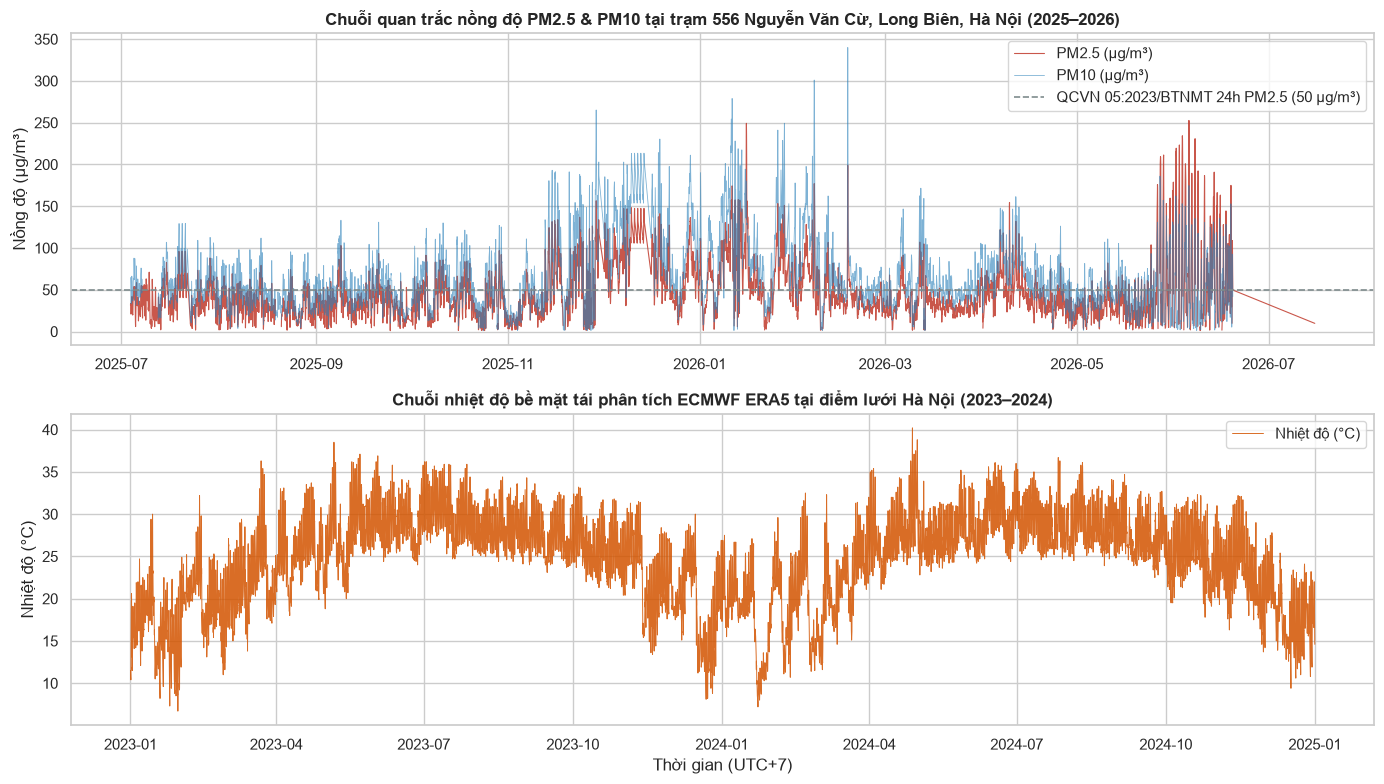

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# Trực quan hóa nồng độ bụi
axes[0].plot(df_air_canonical["timestamp"], df_air_canonical["pm25"], label="PM2.5 (µg/m³)", color="#c0392b", linewidth=0.8, alpha=0.85)
axes[0].plot(df_air_canonical["timestamp"], df_air_canonical["pm10"], label="PM10 (µg/m³)", color="#2980b9", linewidth=0.6, alpha=0.6)
axes[0].axhline(50, color="#7f8c8d", linestyle="--", linewidth=1.2, label="QCVN 05:2023/BTNMT 24h PM2.5 (50 µg/m³)")
axes[0].set_title("Chuỗi quan trắc nồng độ PM2.5 & PM10 tại trạm 556 Nguyễn Văn Cừ, Long Biên, Hà Nội (2025–2026)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Nồng độ (µg/m³)")
axes[0].legend(loc="upper right")

# Trực quan hóa nhiệt độ ERA5
axes[1].plot(df_weather_canonical["timestamp"], df_weather_canonical["temperature"], label="Nhiệt độ (°C)", color="#d35400", linewidth=0.7, alpha=0.85)
axes[1].set_title("Chuỗi nhiệt độ bề mặt tái phân tích ECMWF ERA5 tại điểm lưới Hà Nội (2023–2024)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Nhiệt độ (°C)")
axes[1].set_xlabel("Thời gian (UTC+7)")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 7. Xuất Dữ Liệu Canonical Interim & Ghi Nhận Provenance

In [8]:
# Lưu tệp canonical vào data/interim/
interim_air_path = Path("../data/interim/air_quality_canonical.parquet")
interim_weather_path = Path("../data/interim/weather_canonical.parquet")

df_air_canonical.to_parquet(interim_air_path, index=False, compression="snappy")
df_weather_canonical.to_parquet(interim_weather_path, index=False, compression="snappy")

print(f"Đã lưu interim air quality: {interim_air_path} ({interim_air_path.stat().st_size:,} bytes)")
print(f"Đã lưu interim weather    : {interim_weather_path} ({interim_weather_path.stat().st_size:,} bytes)")

# Kiểm tra metadata.json
with open("../data/raw/metadata.json", "r", encoding="utf-8") as f:
    meta = json.load(f)

exec_log = meta.get("collection_pipeline_execution", {})
print("\n=== THÔNG TIN AUDIT TRONG METADATA.JSON ===")
print("Trạng thái execution   :", exec_log.get("status"))
print("Trạm OpenAQ chuẩn hóa  :", exec_log.get("openaq_ingestion", {}).get("canonical_station_id"))
print("Số bản ghi canonical   :", exec_log.get("openaq_ingestion", {}).get("canonical_records"))
print("Actual min timestamp   :", exec_log.get("openaq_ingestion", {}).get("actual_min_timestamp"))
print("Actual max timestamp   :", exec_log.get("openaq_ingestion", {}).get("actual_max_timestamp"))
print("Disqualification audit :", exec_log.get("disqualification_audit"))

Đã lưu interim air quality: ..\data\interim\air_quality_canonical.parquet (187,581 bytes)
Đã lưu interim weather    : ..\data\interim\weather_canonical.parquet (268,632 bytes)

=== THÔNG TIN AUDIT TRONG METADATA.JSON ===
Trạng thái execution   : completed
Trạm OpenAQ chuẩn hóa  : VN001_HANOI_556_NGUYEN_VAN_CU
Số bản ghi canonical   : 7999
Actual min timestamp   : 2025-07-03 22:00:00+07:00
Actual max timestamp   : 2026-07-15 17:00:00+07:00
Disqualification audit : {'disqualified_location_id': 2178, 'reason': 'Albuquerque, NM, USA (35.1353N, -106.5847W). 100% purged and excluded from Hanoi analysis.'}
